<div class="alert alert-block alert-info" style="margin-top: 20px">

__Ms.MRUNALINI (Data Science Trainer)__
📧 mrunalini0107@gmail.com
📍 Mumbai–400095

<div class="alert alert-block alert-info" style="margin-top: 20px">

## 📘 Simulation of Statistical Models - ANCOVA (Analysis of Covariance)

### 📌 ANCOVA (Analysis of Covariance)

We simulate an ANCOVA model including:
* A factor (Treat)
* A numerical covariate (Conc_Cd2)
* Optional interaction term

__🔹 Step 1: Create the Factor (2 Levels)__

In [ ]:
# Two treatment levels, 18 observations each (total = 36)

Treat <- gl(n = 2, k = 18,
            labels = c("Treat1", "Treat2"))

# Define intercept values for each treatment
Treat_N <- rep(c(3, 4), each = 18)

👉 In ANCOVA, factor levels determine intercepts.

__🔹 Step 2: Create the Covariate (Controlled Case)__

Both treatments must receive identical concentration values.

In [ ]:
set.seed(762)

# Concentrations 0–5, repeated in triplets for each treatment
Conc_Cd2 <- rep(c(0, 1, 2, 3, 4, 5),
                each = 3,
                times = 2)

# Check structure
str(Conc_Cd2)

# Verify alignment
data.frame(Treat, Conc_Cd2)

 num [1:36] 0 0 0 1 1 1 2 2 2 3 ...


Treat,Conc_Cd2
<fct>,<dbl>
Treat1,0
Treat1,0
Treat1,0
Treat1,1
Treat1,1
Treat1,1
Treat1,2
Treat1,2
Treat1,2


### 📌 ANCOVA WITHOUT Interaction (Parallel Slopes)

Model form:
$Y=α_i + βX + ε$

* Intercepts depend on Treat
* Common slope = 0.5

__🔹 Step 3: Simulate Response__

In [ ]:
# ANCOVA Simulation (Without Interaction)
# Model: Y = Intercept(Treat) + 0.5 * Conc_Cd2 + Error

set.seed(452)   # Set seed for reproducibility

Slope <- 0.5    # Common slope for both treatments

# Generate residual errors ~ N(0, 0.5^2)
Residuals <- rnorm(n = length(Treat),
                   mean = 0,
                   sd = 0.5)

# Generate response variable
Response <- round(Treat_N +
                  Slope * Conc_Cd2 +
                  Residuals, 2)

# Combine into data frame
ANCOVA1 <- data.frame(Response,
                      Treat,
                      Conc_Cd2)

# Display first six observations
head(ANCOVA1)

,Response,Treat,Conc_Cd2
,<dbl>,<fct>,<dbl>
1,2.27,Treat1,0
2,2.93,Treat1,0
3,3.86,Treat1,0
4,4.59,Treat1,1
5,3.50,Treat1,1
6,2.69,Treat1,1


__🔹 Step 4: Visualize (Parallel Lines)__

`geom_smooth()` using formula = 'y ~ x'


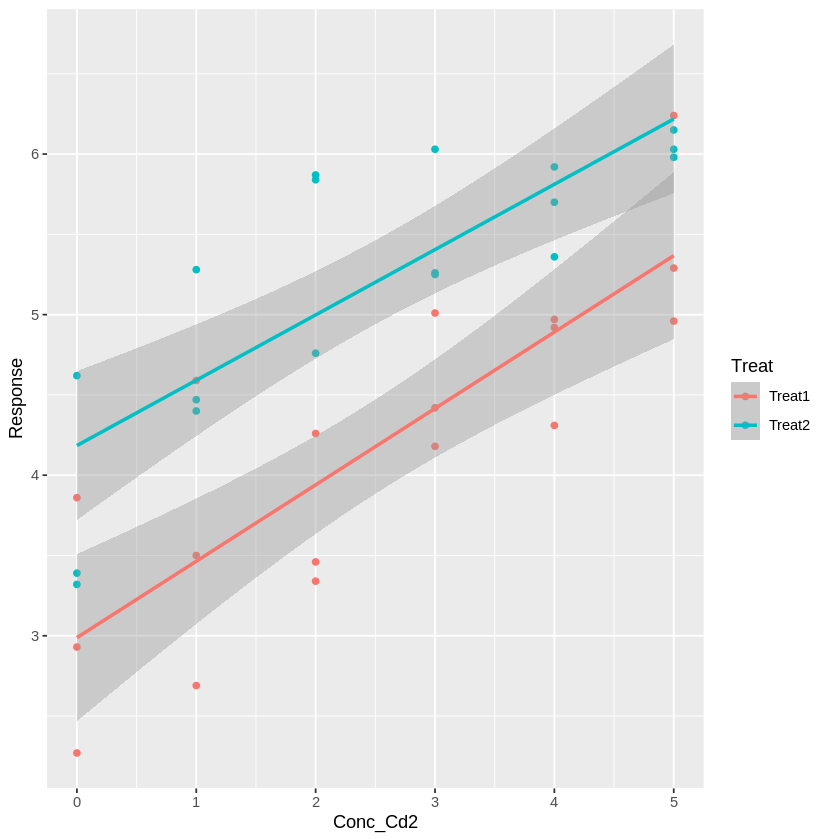

In [ ]:
# Visualization of ANCOVA (Without Interaction)
# Parallel Regression Lines

library(ggplot2)   # Load ggplot2 package

# Create ggplot object
p <- ggplot(data = ANCOVA1,
            aes(x = Conc_Cd2,
                y = Response,
                colour = Treat))

# Add regression lines and data points
p + geom_point() +
    geom_smooth(method = "lm")

# p + geom_point() + geom_smooth(method = "lm", se = FALSE)


Explanation:

* geom_point() → plots observed data
* geom_smooth(method = "lm") → fits linear regression lines
* se = FALSE → removes confidence bands (optional)

This produces parallel regression lines, indicating ANCOVA without interaction.

👉 Parallel regression lines → No interaction

__🔹 Step 5: Fit the Model__

In [ ]:
# ANCOVA Model Fitting
# Model includes:
# - Main effect of Treat (factor)
# - Main effect of Conc_Cd2 (covariate)
# - Interaction term (Treat:Conc_Cd2)

Model1 <- lm(Response ~ Treat + Conc_Cd2 + Treat:Conc_Cd2,
             data = ANCOVA1)

# Display model summary
summary(Model1)


Call:
lm(formula = Response ~ Treat + Conc_Cd2 + Treat:Conc_Cd2, data = ANCOVA1)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.86476 -0.28075 -0.09456  0.34890  1.12594 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)           2.98825    0.23251  12.852 3.52e-14 ***
TreatTreat2           1.19651    0.32882   3.639 0.000955 ***
Conc_Cd2              0.47581    0.07680   6.196 6.17e-07 ***
TreatTreat2:Conc_Cd2 -0.06905    0.10861  -0.636 0.529453    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5564 on 32 degrees of freedom
Multiple R-squared:  0.7518,	Adjusted R-squared:  0.7285 
F-statistic:  32.3 on 3 and 32 DF,  p-value: 8.4e-10


### 📌 ANCOVA WITH Interaction (Different Slopes)

Now slope depends on treatment:

* Treat1 slope = 0.5
* Treat2 slope = 1.5

Model form:
$𝑌 = 𝛼_𝑖 + 𝛽_𝑖𝑋 + 𝜀$

__🔹 Step 6: Define Treatment-Specific Slopes__

In [ ]:
# Define Treatment-Specific Slopes (Interaction Case)
# Treat1 slope = 0.5
# Treat2 slope = 1.5
# -------------------------------------------------

Treat_Int <- rep(c(0.5, 1.5), each = 18)

# Check alignment between factor and slopes
data.frame(Treat, Treat_Int)


Treat,Treat_Int
<fct>,<dbl>
Treat1,0.5
Treat1,0.5
Treat1,0.5
Treat1,0.5
Treat1,0.5
Treat1,0.5
Treat1,0.5
Treat1,0.5
Treat1,0.5


__🔹 Step 7: Simulate Response with Interaction__

In [ ]:
# ANCOVA Simulation WITH Interaction
# Model: Y = Intercept(Treat) + Slope(Treat) * Conc_Cd2 + Error
# Slopes differ between treatments
# -------------------------------------------------

set.seed(452)   # Reproducibility

# Treatment-specific intercepts (from Treat_N)
Intercept <- Treat_N

# Treatment-specific slopes (from Treat_Int)
Slope <- Treat_Int

# Generate residual errors ~ N(0, 0.5^2)
Residuals <- rnorm(n = length(Treat),
                   mean = 0,
                   sd = 0.5)

# Generate response variable
Response <- Intercept +
            Slope * Conc_Cd2 +
            Residuals

# Combine into data frame
ANCOVA2 <- data.frame(Response, Treat, Conc_Cd2)

__🔹 Step 8: Visualize (Non-Parallel Lines)__

`geom_smooth()` using formula = 'y ~ x'


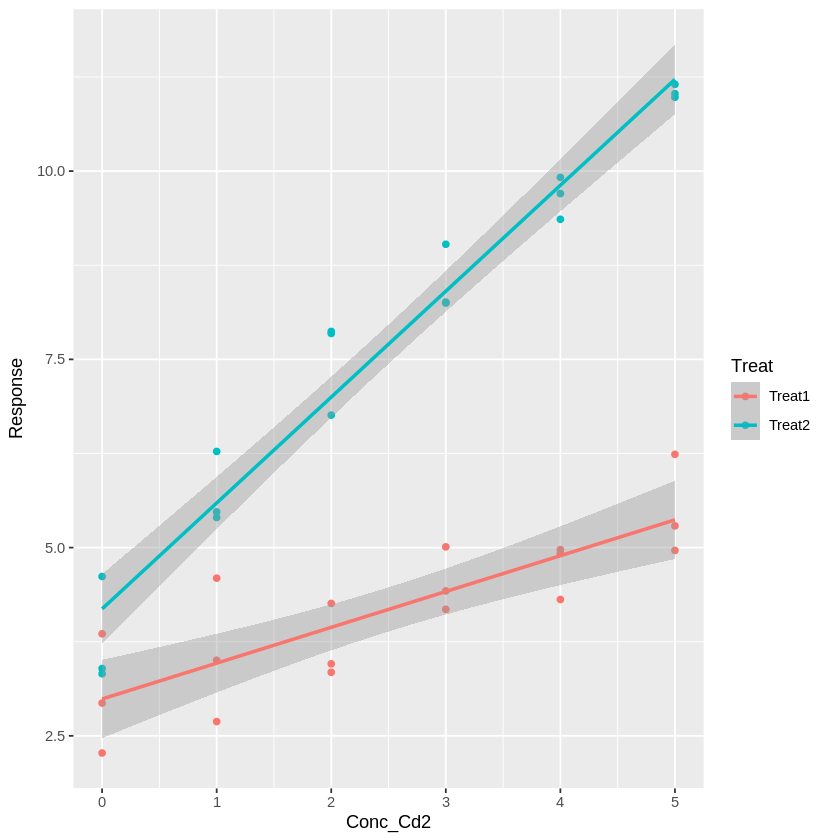

In [ ]:
# Visualization of ANCOVA WITH Interaction
# Non-Parallel Regression Lines
# -------------------------------------------------

library(ggplot2)   # Load ggplot2 (if not already loaded)

# Create ggplot object
p <- ggplot(data = ANCOVA2,
            aes(x = Conc_Cd2,
                y = Response,
                colour = Treat))

# Add data points and regression lines
p + geom_point() +
    geom_smooth(method = "lm")

Explanation:

* geom_point() → plots observed data
* geom_smooth(method = "lm") → fits separate regression lines per treatment
* Different slopes indicate ANCOVA with interaction (non-parallel lines)

👉 Non-parallel lines → Interaction present

__🔹 Step 9: Fit Model with Interaction__

In [ ]:
# ANCOVA Model WITH Interaction
# Model includes:
# - Main effect of Treat (different intercepts)
# - Main effect of Conc_Cd2 (baseline slope)
# - Interaction term (Treat:Conc_Cd2 → different slopes)
# -------------------------------------------------

Model2 <- lm(Response ~ Treat + Conc_Cd2 + Treat:Conc_Cd2,
             data = ANCOVA2)

# Display model summary
summary(Model2)


Call:
lm(formula = Response ~ Treat + Conc_Cd2 + Treat:Conc_Cd2, data = ANCOVA2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.86132 -0.28116 -0.09476  0.34576  1.12860 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)            2.9896     0.2322  12.873 3.37e-14 ***
TreatTreat2            1.1964     0.3284   3.643 0.000944 ***
Conc_Cd2               0.4757     0.0767   6.202 6.06e-07 ***
TreatTreat2:Conc_Cd2   0.9307     0.1085   8.580 8.35e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5558 on 32 degrees of freedom
Multiple R-squared:  0.9584,	Adjusted R-squared:  0.9544 
F-statistic: 245.4 on 3 and 32 DF,  p-value: < 2.2e-16


Now the interaction term should be significant.

### 📌 ANCOVA with Interaction but Common Intercept

Instead of different intercepts, use one intercept (e.g., 6).

__🔹 Step 10: Simulate with One Intercept__

In [ ]:
# ANCOVA WITH Interaction and Common Intercept
# Model: Y = 6 + Slope(Treat) * Conc_Cd2 + Error
# Same intercept for both treatments
# Different slopes (interaction present)
# -------------------------------------------------

set.seed(452)   # Reproducibility

Intercept <- 6          # Common intercept
Slope <- Treat_Int      # Treatment-specific slopes

# Generate residual errors ~ N(0, 0.5^2)
Residuals <- rnorm(n = length(Treat),
                   mean = 0,
                   sd = 0.5)

# Generate response variable
Response <- Intercept +
            Slope * Conc_Cd2 +
            Residuals

# Combine into data frame
ANCOVA3 <- data.frame(Response, Treat, Conc_Cd2)


__🔹 Step 11: Plot__

`geom_smooth()` using formula = 'y ~ x'


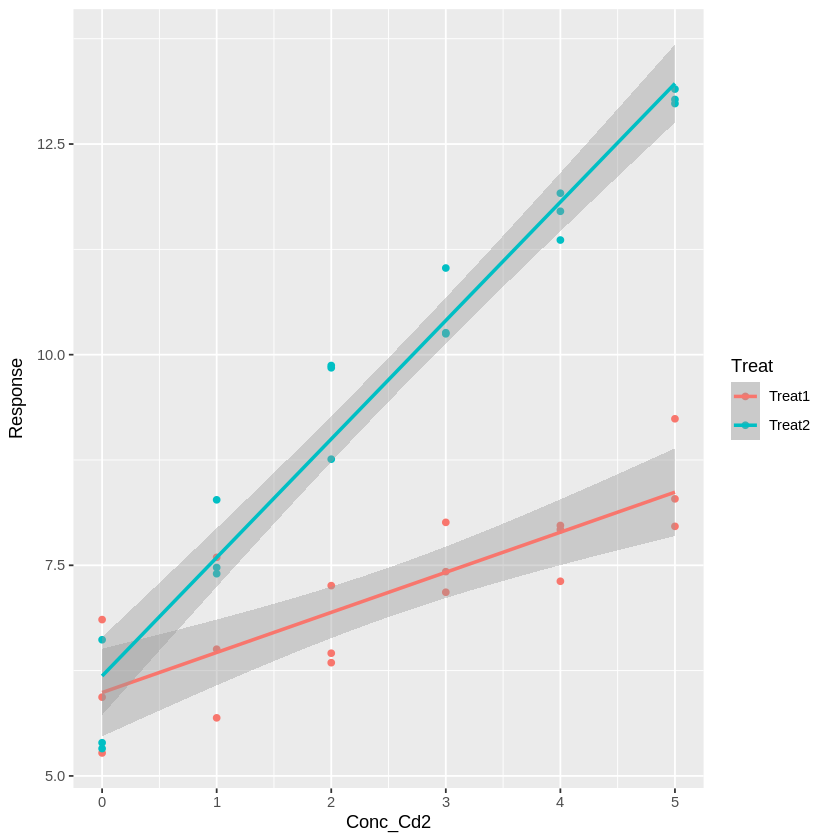

In [ ]:
# Visualization of ANCOVA3
# Common Intercept, Different Slopes (Interaction)
# -------------------------------------------------

library(ggplot2)   # Load ggplot2 (if not already loaded)

# Create ggplot object
p <- ggplot(data = ANCOVA3,
            aes(x = Conc_Cd2,
                y = Response,
                colour = Treat))

# Add points and fitted regression lines
p + geom_point() +
    geom_smooth(method = "lm")

Interpretation:

* Both lines start from approximately the same intercept (≈ 6).
* Slopes differ between treatments.
* Non-parallel lines indicate a significant interaction effect.

__🔹 Step 12: Fit Model__

In [ ]:
# ANCOVA Model 3
# Common Intercept + Interaction (Different Slopes)
# -------------------------------------------------

Model3 <- lm(Response ~ Treat + Conc_Cd2 + Treat:Conc_Cd2,
             data = ANCOVA3)

# Display model summary
summary(Model3)



Call:
lm(formula = Response ~ Treat + Conc_Cd2 + Treat:Conc_Cd2, data = ANCOVA3)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.86132 -0.28116 -0.09476  0.34576  1.12860 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)            5.9896     0.2322  25.792  < 2e-16 ***
TreatTreat2            0.1964     0.3284   0.598    0.554    
Conc_Cd2               0.4757     0.0767   6.202 6.06e-07 ***
TreatTreat2:Conc_Cd2   0.9307     0.1085   8.580 8.35e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5558 on 32 degrees of freedom
Multiple R-squared:  0.946,	Adjusted R-squared:  0.9409 
F-statistic: 186.7 on 3 and 32 DF,  p-value: < 2.2e-16


### 📌 Model Meaning

This model estimates:
$Y= 𝛽_0 + 𝛽_1 Treat + 𝛽_2 𝑋 + 𝛽_3 ( Treat × 𝑋 ) + 𝜀$

Where:

β₀ → intercept for reference treatment

β₁ → intercept difference (may be small since we simulated common intercept)

β₂ → slope for reference treatment

β₃ → slope difference between treatments

Residual standard error ≈ 0.5 (as simulated)

Since slopes were simulated differently, the interaction term should be significant, while intercept difference may not be.


📊 Summary of ANCOVA Models

| Model Type          | Intercepts        | Slopes    | Lines        |
| ------------------- | ----------------- | --------- | ------------ |
| Without Interaction | Different         | Same      | Parallel     |
| With Interaction    | Different or Same | Different | Non-parallel |


### 📌 General ANCOVA Model

* Without interaction: $Y_{ij​} = α_i​ + βX_{ij}​ + ε_{ij}$​

* With interaction: $Y_{ij}​ = α_i​ + β_iX_{ij}​ + ε_{ij}$​

where $ε_{ij}​∼N(0,σ^2)$


<div class="alert alert-block alert-info" style="margin-top: 20px">
    
### THANK YOU ...! 

__Ms.MRUNALINI (Data Science Trainer)__
📧 mrunalini0107@gmail.com
📍 Mumbai–400095